# Finding quantum states
## Shooting, matrices, and new potentials

**One goal:** test a solver on a problem we know, then use it on a problem we cannot solve by hand.

1. **See:** why only certain energies satisfy both boundary conditions.
2. **Compare:** shooting and the matrix method on the same grid.
3. **Explore:** change the potential and predict how the quantum states change.

Use **Restart Kernel → Run All** first. Then change a line marked **TRY** and rerun that section.
All code and figures are in this notebook. No data files or widgets are required.

**Requirements:** Python 3.12, NumPy 2 or later, SciPy, Matplotlib, Numba, and Jupyter.
The Numba comparison is in Section 4. Section 8 adds double wells and a potential gallery;
its final time-dependent example is optional.
For one class, choose the anharmonic oscillator or the double well as the main application.
The other potentials can be used for short demonstrations or later practice.

### Setup

**Learn**
- NumPy stores functions on a grid; Matplotlib draws them.
- `eigh_tridiagonal` is the same matrix solver used for hydrogen.
- All positions and energies below are in scaled units.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh_tridiagonal
from timeit import repeat

plt.rcParams.update({
    "font.family": "serif", "font.size": 12, "figure.dpi": 130,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.linewidth": 0.9, "lines.linewidth": 1.7,
    "xtick.direction": "out", "ytick.direction": "out",
    "xtick.top": False, "ytick.right": False,
})
BLUE, RED, BLACK = "#245B87", "#8B0029", "#1D1D1F"
np.set_printoptions(precision=6, suppress=True)

## 1. One equation, two boundaries

For hydrogen, we supplied a potential and found allowed energies and wavefunctions.
We now use a simpler one-dimensional box to see **how an energy is selected**.

$$-\frac12\frac{d^2\psi}{dx^2}+V(x)\psi=E\psi.$$

- Inside the box, the potential is zero.
- The walls are at the left and right ends.
- The wavefunction must be zero at **both** walls.

$$V(x)=0\quad(0<x<1),\qquad \psi(0)=\psi(1)=0.$$

Position is measured in a chosen length unit; energy is measured in the corresponding
unit that makes the kinetic coefficient one half. For the oscillator later,
these are the usual oscillator length and energy units.

### Start with a state we already know

**Learn**
- The ground state has no internal node.
- The exact energy is a check, not an input to our solver.

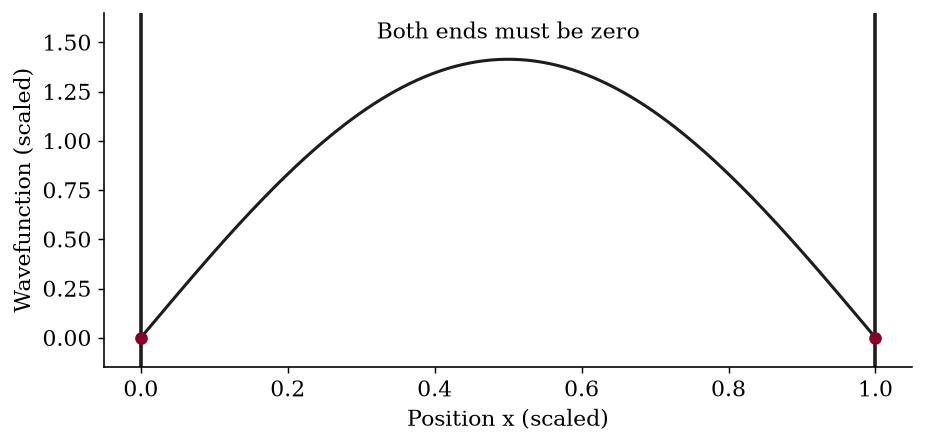

Exact ground-state energy: 4.93480220


In [2]:
x_view = np.linspace(0, 1, 301)
psi_view = np.sqrt(2) * np.sin(np.pi * x_view)
E_exact = np.pi**2 / 2

fig, ax = plt.subplots(figsize=(7, 3.3), layout="constrained")
ax.plot(x_view, psi_view, color=BLACK)
ax.axvline(0, color=BLACK, linewidth=2)
ax.axvline(1, color=BLACK, linewidth=2)
ax.scatter([0, 1], [0, 0], color=RED, zorder=3)
ax.set(xlabel="Position x (scaled)", ylabel="Wavefunction (scaled)",
       xlim=(-0.05, 1.05), ylim=(-0.15, 1.65))
ax.text(0.5, 1.52, "Both ends must be zero", ha="center")
plt.show()
print(f"Exact ground-state energy: {E_exact:.8f}")

**Read the figure.** The red dots are the two boundary conditions. A curve that misses either dot is not an allowed state.

## 2. Guess an energy and shoot

**Shooting means:** choose an energy, build a trial wavefunction from left to right,
and see whether it reaches zero at the right wall.

We reuse the three-point difference from the hydrogen notebook. Rearranging it gives
the next sample from the two previous samples:

$$\psi_{i+1}=2\psi_i-\psi_{i-1}+2h^2(V_i-E)\psi_i.$$

The left wall fixes the first sample to zero. We choose a small positive second sample
to start the curve. This sets an arbitrary amplitude; we normalize **after** finding an allowed energy.

### Compute one step by hand

**Learn**
- `h` is the spacing between neighboring samples.
- The next value uses only two known values and the chosen energy.

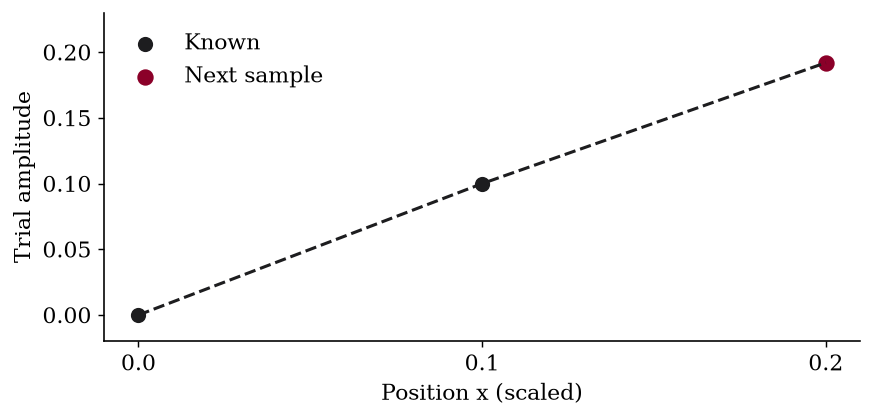

psi[2] = 0.192


In [3]:
h_demo = 0.1
E_demo = 4.0
psi0 = 0.0
psi1 = h_demo
psi2 = 2*psi1 - psi0 - 2*h_demo**2*E_demo*psi1

fig, ax = plt.subplots(figsize=(6.6, 3.1), layout="constrained")
ax.plot([0, h_demo, 2*h_demo], [psi0, psi1, psi2], "--", color=BLACK)
ax.scatter([0, h_demo], [psi0, psi1], color=BLACK, s=55, label="Known")
ax.scatter([2*h_demo], [psi2], color=RED, s=65, label="Next sample")
ax.set(xlabel="Position x (scaled)", ylabel="Trial amplitude",
       xticks=[0, h_demo, 2*h_demo], ylim=(-0.02, 0.23))
ax.legend(frameon=False)
plt.show()
print(f"psi[2] = {psi2:.3f}")

**Read the figure.** This is one numerical step, not a complete eigenstate. Repeating the same step builds the trial curve.

### Repeat that step to the right wall

**Learn**
- This function is the same recurrence inside a short loop.
- The returned last value tells us whether the right boundary is satisfied.
- For now, use it only for the finite box.

In [4]:
def shoot(energy, x, potential):
    h = x[1] - x[0]
    psi = np.zeros(len(x))
    psi[0] = 0.0
    psi[1] = h
    for i in range(1, len(x) - 1):
        psi[i+1] = (2*psi[i] - psi[i-1]
                    + 2*h**2*(potential[i] - energy)*psi[i])
    return psi

x_box = np.linspace(0, 1, 201)
V_box = np.zeros_like(x_box)

### Try an energy: does the curve hit zero?

**Learn**
- **TRY:** change `E_try` to 4.5, 4.9, or 5.5.
- Every trial starts with the same two left-hand samples.
- Positive or negative endpoint values are both boundary errors.

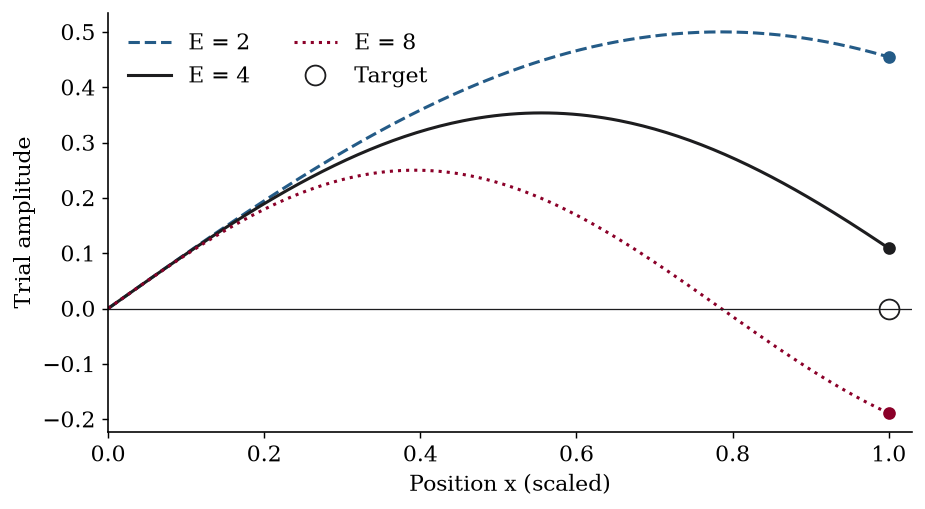

Right endpoint for E_try: +0.108915


In [5]:
E_try = 4.0  # TRY: 4.5, 4.9, 5.5
trials = [2.0, E_try, 8.0]
fig, ax = plt.subplots(figsize=(7, 3.8), layout="constrained")
for energy, color, style in zip(trials, [BLUE, BLACK, RED], ["--", "-", ":"]):
    trial = shoot(energy, x_box, V_box)
    ax.plot(x_box, trial, style, color=color, label=f"E = {energy:g}")
    ax.scatter([1], [trial[-1]], color=color, zorder=3)
ax.axhline(0, color=BLACK, linewidth=0.7)
ax.plot(1, 0, "o", ms=11, mfc="none", mec=BLACK, label="Target")
ax.set(xlabel="Position x (scaled)", ylabel="Trial amplitude", xlim=(0, 1.03))
ax.legend(frameon=False, ncols=2)
plt.show()
print(f"Right endpoint for E_try: {shoot(E_try, x_box, V_box)[-1]:+.6f}")

**Read the figure.** Changing the energy changes the curve. The open circle at the right wall is the target. Trial curves are not normalized probability amplitudes.

### Turn the boundary condition into a root

**Learn**
- For each energy, keep just the last value of the trial curve.
- A zero crossing is an allowed energy on this grid.
- The interval from 2 to 8 contains the first crossing.

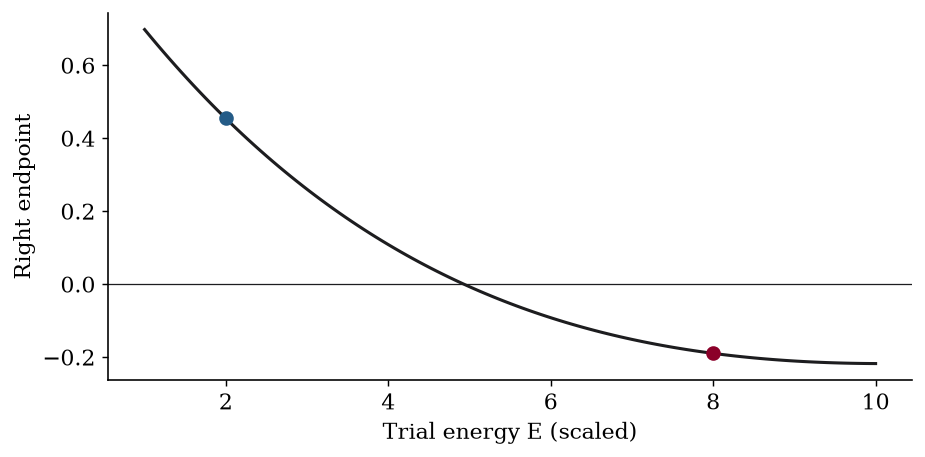

In [6]:
energy_scan = np.linspace(1, 10, 121)
endpoint_scan = [shoot(e, x_box, V_box)[-1] for e in energy_scan]

fig, ax = plt.subplots(figsize=(7, 3.4), layout="constrained")
ax.plot(energy_scan, endpoint_scan, color=BLACK)
ax.axhline(0, color=BLACK, linewidth=0.7)
for e, color in [(2.0, BLUE), (8.0, RED)]:
    ax.scatter(e, shoot(e, x_box, V_box)[-1], color=color, s=50, zorder=3)
ax.set(xlabel="Trial energy E (scaled)", ylabel="Right endpoint")
plt.show()

**Read the figure.** We have changed an eigenvalue problem into a root-finding problem. This is the same sign-change idea used in bisection earlier in the course.

### Reuse bisection

**Learn**
- Keep an interval whose endpoint errors have opposite signs.
- Test the midpoint, then keep the half containing the sign change.
- The bracket must isolate the state we want; a sign change alone does not count states.

In [7]:
def bisect_energy(left, right, x, potential, steps=38):
    f_left = shoot(left, x, potential)[-1]
    f_right = shoot(right, x, potential)[-1]
    if f_left * f_right >= 0:
        raise ValueError("Choose a bracket with opposite endpoint signs.")
    history = []
    for j in range(steps):
        middle = (left + right) / 2
        f_middle = shoot(middle, x, potential)[-1]
        history.append([left, right, middle, f_middle])
        if f_middle == 0:
            break
        if f_left * f_middle < 0:
            right = middle
        else:
            left = middle
            f_left = f_middle
    return middle, np.array(history)

### Watch the energy bracket shrink

**Learn**
- Each horizontal line is one energy interval.
- The dot is the energy tested at its midpoint.

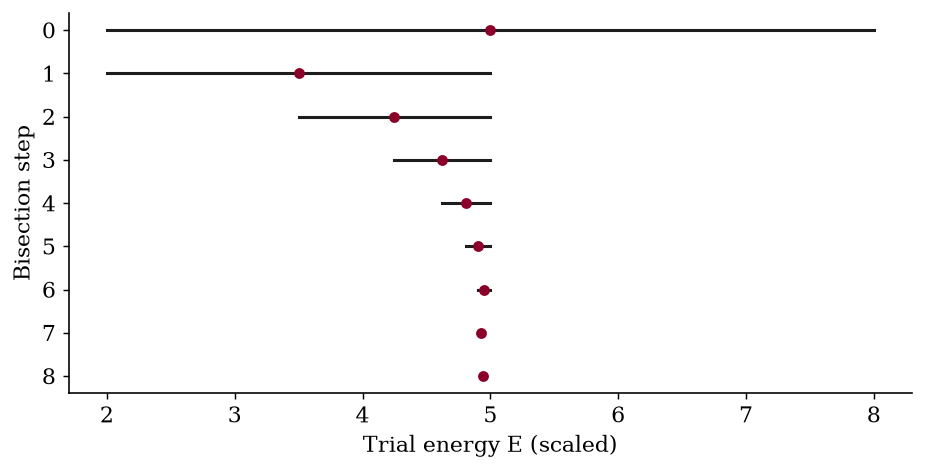

Shooting energy: 4.93470073
Exact energy:    4.93480220


In [8]:
E_shoot, history = bisect_energy(2.0, 8.0, x_box, V_box)
fig, ax = plt.subplots(figsize=(7, 3.5), layout="constrained")
for j, (left, right, middle, residual) in enumerate(history[:9]):
    ax.plot([left, right], [j, j], color=BLACK)
    ax.scatter(middle, j, color=RED, s=25, zorder=3)
ax.set(xlabel="Trial energy E (scaled)", ylabel="Bisection step",
       yticks=np.arange(9))
ax.invert_yaxis()
plt.show()
print(f"Shooting energy: {E_shoot:.8f}")
print(f"Exact energy:    {E_exact:.8f}")

**Read the figure.** The search interval shrinks by a factor of two at each step. A narrow search interval does not remove the error caused by a coarse spatial grid.

### Normalize and check the result

**Learn**
- The integral of probability must be one.
- Only now do we compare with the exact wavefunction.

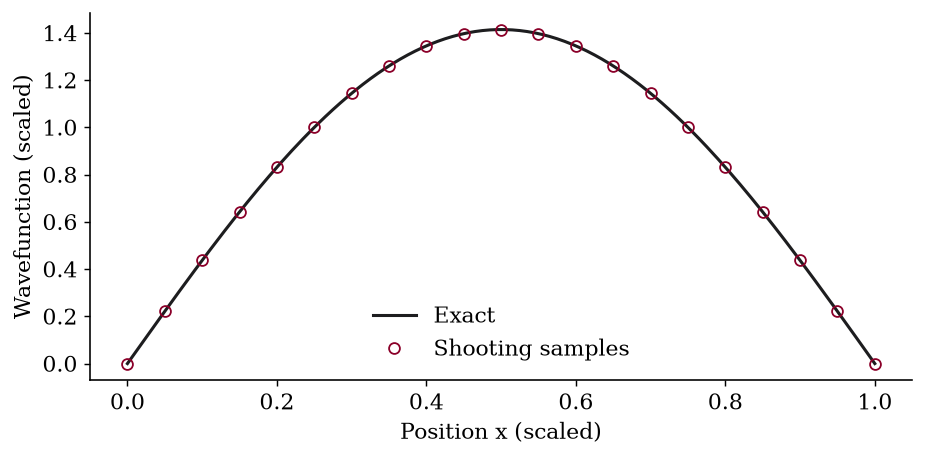

Probability integral: 1.0
Absolute energy error: 1.015e-04


In [9]:
psi_shoot = shoot(E_shoot, x_box, V_box)
psi_shoot /= np.sqrt(np.trapezoid(psi_shoot**2, x_box))
psi_exact = np.sqrt(2) * np.sin(np.pi * x_box)

fig, ax = plt.subplots(figsize=(7, 3.4), layout="constrained")
ax.plot(x_box, psi_exact, color=BLACK, label="Exact")
ax.plot(x_box[::10], psi_shoot[::10], "o", mfc="none", color=RED,
        label="Shooting samples")
ax.set(xlabel="Position x (scaled)", ylabel="Wavefunction (scaled)")
ax.legend(frameon=False)
plt.show()
print("Probability integral:", np.trapezoid(psi_shoot**2, x_box))
print(f"Absolute energy error: {abs(E_shoot - E_exact):.3e}")

**Read the figure.** Check both the energy and the wavefunction. In this special zero-potential box, the discrete eigenvector has the sampled sine shape even though its energy still has a grid error.

## 3. The same problem as a matrix

The matrix method writes the same three-point equations for **all** interior samples at once.
The wall values are already known, so they are not unknowns in the matrix.

$$H_{ii}=h^{-2}+V_i,\qquad H_{i,i+1}=H_{i+1,i}=-\frac{1}{2h^2}.$$

We solve for an energy and a vector of samples together:

$$H\boldsymbol\psi=E\boldsymbol\psi.$$

### Only neighbors are connected

**Learn**
- Use five interior points so that we can inspect every matrix entry.
- Each row is one three-point equation. Zeros mean no direct coupling.

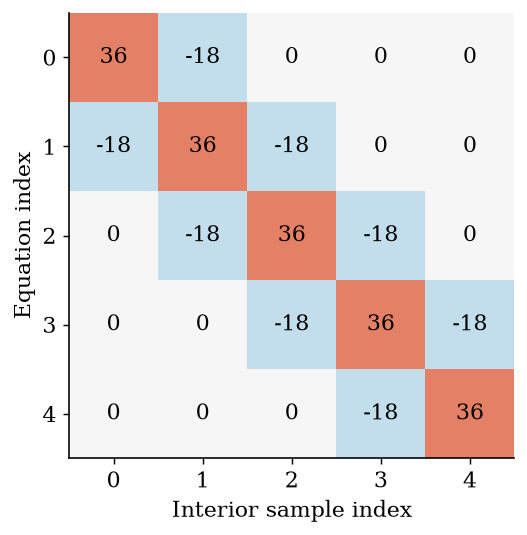

In [10]:
h_small = 1 / 6
H_small = np.diag(np.full(5, 1/h_small**2))
H_small += np.diag(np.full(4, -0.5/h_small**2), 1)
H_small += np.diag(np.full(4, -0.5/h_small**2), -1)

fig, ax = plt.subplots(figsize=(5.2, 4.0), layout="constrained")
ax.imshow(H_small, cmap="RdBu_r", vmin=-72, vmax=72)
for i in range(5):
    for j in range(5):
        ax.text(j, i, f"{H_small[i, j]:.0f}", ha="center", va="center")
ax.set(xticks=range(5), yticks=range(5),
       xlabel="Interior sample index", ylabel="Equation index")
plt.show()

**Read the figure.** The diagonal and its two neighbors contain all nonzero entries. We draw a small full matrix here, but the solver stores only two one-dimensional arrays.

### Reuse the hydrogen matrix solver

**Learn**
- Only the potential array changes from problem to problem.
- The returned wavefunctions include the two zero endpoints.
- We convert vector normalization into probability normalization.

In [11]:
def matrix_states(x, potential, n_states=1):
    h = x[1] - x[0]
    diagonal = 1/h**2 + potential[1:-1]
    off_diagonal = np.full(len(diagonal) - 1, -0.5/h**2)
    energies, vectors = eigh_tridiagonal(
        diagonal, off_diagonal, select="i", select_range=(0, n_states - 1))
    waves = np.zeros((len(x), n_states))
    waves[1:-1] = vectors / np.sqrt(h)
    for j in range(n_states):
        peak = np.argmax(np.abs(waves[:, j]))
        if waves[peak, j] < 0:
            waves[:, j] *= -1
    return energies, waves

E_box_matrix, psi_box_matrix = matrix_states(x_box, V_box, n_states=3)
print("First three energies:", E_box_matrix)

First three energies: [ 4.934701 19.737585 44.405002]


### Two methods, the same ground state

**Learn**
- Both methods use the same grid, boundaries, and three-point equation.
- They should give the same discrete answer, up to solver tolerances.

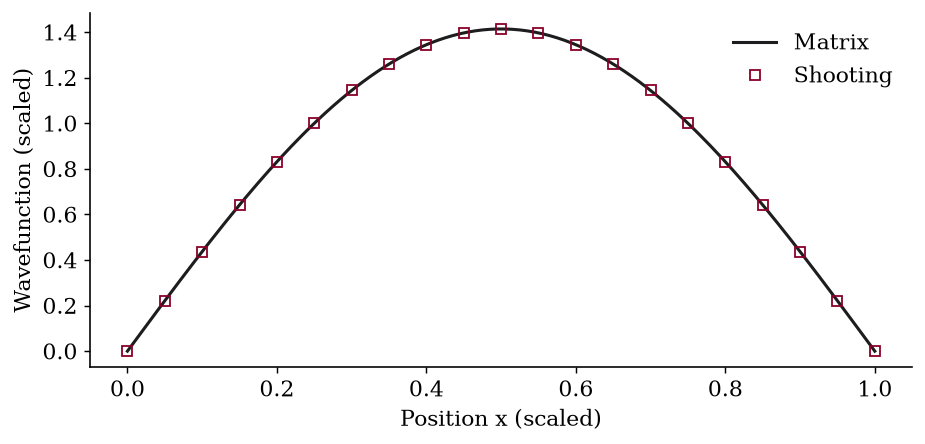

Matrix energy:   4.9347007336
Shooting energy: 4.9347007336
Difference:      1.722e-11


In [12]:
fig, ax = plt.subplots(figsize=(7, 3.3), layout="constrained")
ax.plot(x_box, psi_box_matrix[:, 0], color=BLACK, label="Matrix")
ax.plot(x_box[::10], psi_shoot[::10], "s", mfc="none", color=RED,
        label="Shooting")
ax.set(xlabel="Position x (scaled)", ylabel="Wavefunction (scaled)")
ax.legend(frameon=False)
plt.show()
print(f"Matrix energy:   {E_box_matrix[0]:.10f}")
print(f"Shooting energy: {E_shoot:.10f}")
print(f"Difference:      {abs(E_box_matrix[0] - E_shoot):.3e}")

**Read the figure.** Agreement checks the two implementations. Because they share the same difference formula, agreement alone does not prove that the grid is fine enough.

### Several states are convenient with a matrix

**Learn**
- The next states have one and two internal nodes.
- A node is a zero of the wavefunction inside the box.

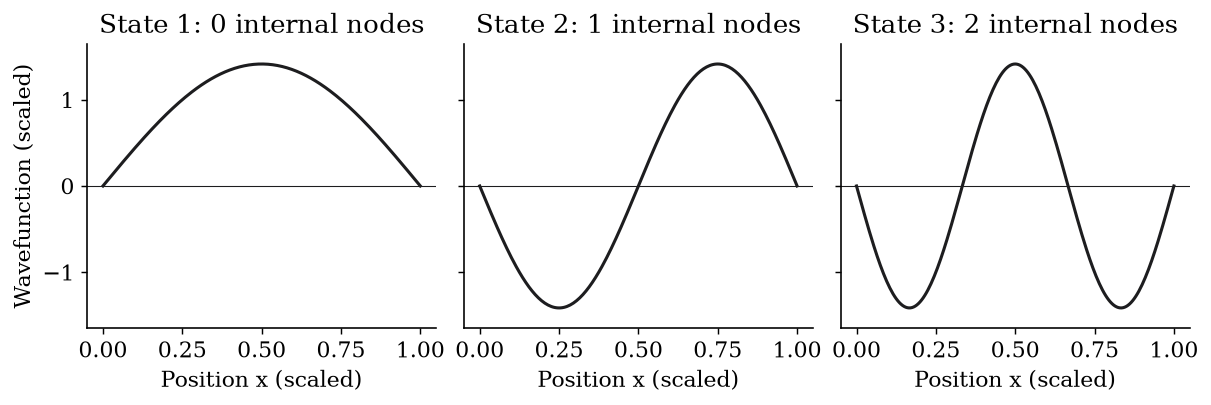

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(9.2, 3), sharey=True,
                         layout="constrained")
for j, ax in enumerate(axes):
    ax.plot(x_box, psi_box_matrix[:, j], color=BLACK)
    ax.axhline(0, color=BLACK, linewidth=0.6)
    ax.set(title=f"State {j+1}: {j} internal nodes",
           xlabel="Position x (scaled)", ylim=(-1.65, 1.65))
axes[0].set_ylabel("Wavefunction (scaled)")
plt.show()

**Read the figure.** The three panels use the same vertical scale. A global sign change of a wavefunction does not change its probability density.

## 4. Accuracy and calculation cost

**Accuracy:** keep the box fixed and increase the number of grid intervals.
Both methods use the same second-order difference formula, so both have the same leading grid error.

**Cost:** one shooting pass visits every grid point; the energy search repeats this pass.
The tridiagonal matrix solver also uses the neighbor structure and can request just the lowest state.
It does not need a full dense matrix or all eigenstates.

### Double the number of intervals

**Learn**
- The exact box energy is the reference.
- Keep the energy search accurate enough that spatial error dominates.

In [14]:
intervals = np.array([20, 40, 80, 160, 320])
error_shoot, error_matrix = [], []
for count in intervals:
    x = np.linspace(0, 1, count + 1)
    potential = np.zeros_like(x)
    es, _ = bisect_energy(2.0, 8.0, x, potential)
    em, _ = matrix_states(x, potential)
    error_shoot.append(abs(es - E_exact))
    error_matrix.append(abs(em[0] - E_exact))
error_shoot = np.array(error_shoot)
error_matrix = np.array(error_matrix)
print("Matrix error reduction factors:", error_matrix[:-1]/error_matrix[1:])

Matrix error reduction factors: [3.997533 3.999383 3.999846 3.999962]


### Both errors shrink together

**Learn**
- Doubling the intervals makes the spacing half as large.
- For this three-point method, the error becomes about four times smaller.

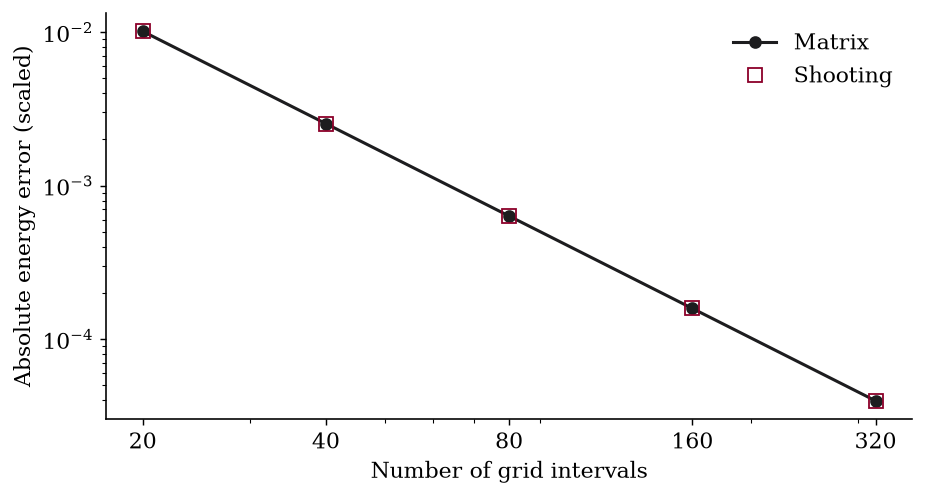

In [15]:
fig, ax = plt.subplots(figsize=(7, 3.7), layout="constrained")
ax.loglog(intervals, error_matrix, "o-", color=BLACK, label="Matrix")
ax.loglog(intervals, error_shoot, "s", ms=8, mfc="none", color=RED,
          label="Shooting")
ax.set(xlabel="Number of grid intervals", ylabel="Absolute energy error (scaled)")
ax.set_xticks(intervals, [str(n) for n in intervals])
ax.xaxis.set_minor_formatter(plt.NullFormatter())
ax.legend(frameon=False)
plt.show()

**Read the figure.** Shooting is a way to find an eigenvalue; it is not automatically a more accurate discretization. Improving the difference formula is a separate topic.

### Time the same task

**Learn**
- Every method returns one energy and one normalized wavefunction on the same grid.
- This is the same 38-step bisection, without saving its plotting history.
- The final argument chooses the Python or compiled shooting function; the algorithm stays the same.

In [16]:
def shooting_state(x, potential, integrate):
    left, right = 2.0, 8.0  # Bracket for the box ground state only.
    f_left = integrate(left, x, potential)[-1]
    if f_left * integrate(right, x, potential)[-1] >= 0:
        raise ValueError("The bracket must have opposite endpoint signs.")
    for _ in range(38):
        energy = (left + right) / 2
        f_middle = integrate(energy, x, potential)[-1]
        if f_middle == 0:
            break
        if f_left * f_middle < 0:
            right = energy
        else:
            left, f_left = energy, f_middle
    psi = integrate(energy, x, potential)
    h = x[1] - x[0]
    norm2 = h * (np.sum(psi**2) - (psi[0]**2 + psi[-1]**2)/2)
    psi /= np.sqrt(norm2)  # Trapezoid rule on this uniform grid.
    return energy, psi

### Compile once, then measure repeated use

**Learn**
- `njit` compiles the same numerical loops to machine code, including the energy search.
- The first call includes compilation. Record it separately from the later calls.
- Compilation should change the speed, not the equations or the answer.

In [17]:
from numba import njit
from time import perf_counter

shoot_numba = njit(shoot)
shooting_numba = njit(shooting_state)
x_timing = np.linspace(0, 1, 201)
v_timing = np.zeros_like(x_timing)
start = perf_counter()
e_fast, p_fast = shooting_numba(x_timing, v_timing, shoot_numba)
first_call_ms = 1000 * (perf_counter() - start)
e_python, p_python = shooting_state(x_timing, v_timing, shoot)
assert abs(e_fast - e_python) < 1e-10
assert np.max(np.abs(p_fast - p_python)) < 1e-9
print(f"First Numba call, including compilation: {first_call_ms:.1f} ms")
print(f"Energy difference after compilation: {abs(e_fast-e_python):.2e}")

First Numba call, including compilation: 403.3 ms
Energy difference after compilation: 0.00e+00


### Warm up all three implementations

**Learn**
- Use the median of five batches, each containing ten solves.
- The matrix code calls compiled LAPACK; Numba removes Python loop overhead from shooting.
- The original Python version remains in the comparison to show the effect of compilation.

In [18]:
def milliseconds(function):
    function()  # Warm up before measuring.
    samples = repeat(function, number=10, repeat=5)
    return 1000 * np.median(samples) / 10

timing_sizes = [200, 800, 3200]
shoot_ms, numba_ms, matrix_ms = [], [], []
for count in timing_sizes:
    x = np.linspace(0, 1, count + 1)
    potential = np.zeros_like(x)
    shoot_ms.append(milliseconds(lambda: shooting_state(x, potential, shoot)))
    numba_ms.append(milliseconds(lambda: shooting_numba(x, potential, shoot_numba)))
    matrix_ms.append(milliseconds(lambda: matrix_states(x, potential)))

### Measure on your own computer

**Learn**
- Times vary with the computer, implementation, and requested accuracy.
- The plot excludes first-call compilation; that cost is printed separately above.
- The earlier hydrogen code already used an efficient tridiagonal solver.

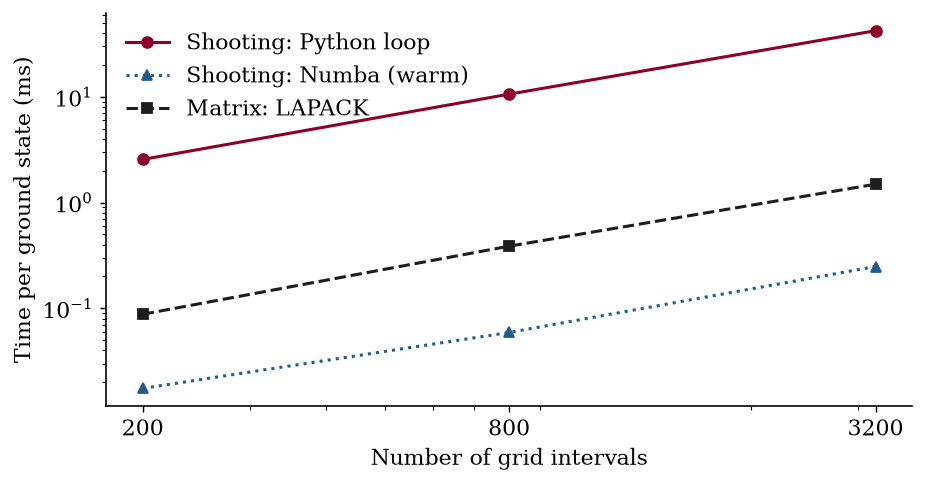

Intervals | Python (ms) | Numba (ms) | Matrix (ms)
      200 |       2.555 |      0.017 |       0.088
      800 |      10.585 |      0.059 |       0.387
     3200 |      42.151 |      0.248 |       1.491


In [19]:
fig, ax = plt.subplots(figsize=(7, 3.6), layout="constrained")
ax.loglog(timing_sizes, shoot_ms, "o-", color=RED, label="Shooting: Python loop")
ax.loglog(timing_sizes, numba_ms, "^:", color=BLUE, label="Shooting: Numba (warm)")
ax.loglog(timing_sizes, matrix_ms, "s--", color=BLACK, label="Matrix: LAPACK")
ax.set(xlabel="Number of grid intervals", ylabel="Time per ground state (ms)")
ax.set_xticks(timing_sizes, [str(n) for n in timing_sizes])
ax.xaxis.set_minor_formatter(plt.NullFormatter())
ax.legend(frameon=False)
plt.show()
print("Intervals | Python (ms) | Numba (ms) | Matrix (ms)")
for n, ts, tn, tm in zip(timing_sizes, shoot_ms, numba_ms, matrix_ms):
    print(f"{n:9d} | {ts:11.3f} | {tn:10.3f} | {tm:11.3f}")

**Read the figure.** All three return the same kind of result and include preparation and normalization. Warm Numba time excludes compilation. Python and Numba run the identical shooting code; all three share the same spatial discretization, while bisection and LAPACK use different stopping rules. This is a benchmark of these implementations on this machine, not a universal ranking. For only one solve, include the first-call cost.

| Question | Shooting | Tridiagonal matrix |
|---|---|---|
| Main idea | Guess energy and satisfy the far boundary | Solve all sample equations together |
| Work | Repeat a grid sweep during the energy search | Use a solver specialized for neighboring samples |
| Stored data | A grid and one trial curve here | Two matrix diagonals and requested wavefunctions |
| Accuracy in this notebook | Same three-point grid error | Same three-point grid error |
| Several states | Separate brackets and node checks | Request several states in one call |

**Pause:** did compilation improve the spatial accuracy?
No. It changed how the same instructions run. Accuracy still depends on the grid and the energy search.
Shooting makes boundary conditions explicit; its stability and efficiency depend on the equation and integration direction.

## 5. Check the solver on the harmonic oscillator

Before changing the physics, check another problem with a known answer.

$$V(x)=\frac12x^2,\qquad E_n=n+\frac12,\qquad n=0,1,2,\ldots$$

We use a finite computational interval with zero endpoint values. The physical oscillator extends to infinity.
The interval must be wide enough that the low-energy states have negligible tails at its edges.

### Change the grid and potential, keep the solver

**Learn**
- The oscillator extends to both sides of the origin.
- Ask for four states using the same matrix function.

In [20]:
x_osc = np.linspace(-6, 6, 801)
V_harmonic = 0.5 * x_osc**2
E_harmonic, psi_harmonic = matrix_states(x_osc, V_harmonic, n_states=4)
E_harmonic_exact = np.arange(4) + 0.5
for n in range(4):
    print(f"n = {n}: numerical {E_harmonic[n]:.6f}; exact {E_harmonic_exact[n]:.6f}")

n = 0: numerical 0.499993; exact 0.500000
n = 1: numerical 1.499965; exact 1.500000
n = 2: numerical 2.499909; exact 2.500000
n = 3: numerical 3.499824; exact 3.500000


### Check the ground-state probability density

**Learn**
- Probability density is the square of the wavefunction.
- Compare the numerical density with the exact Gaussian.

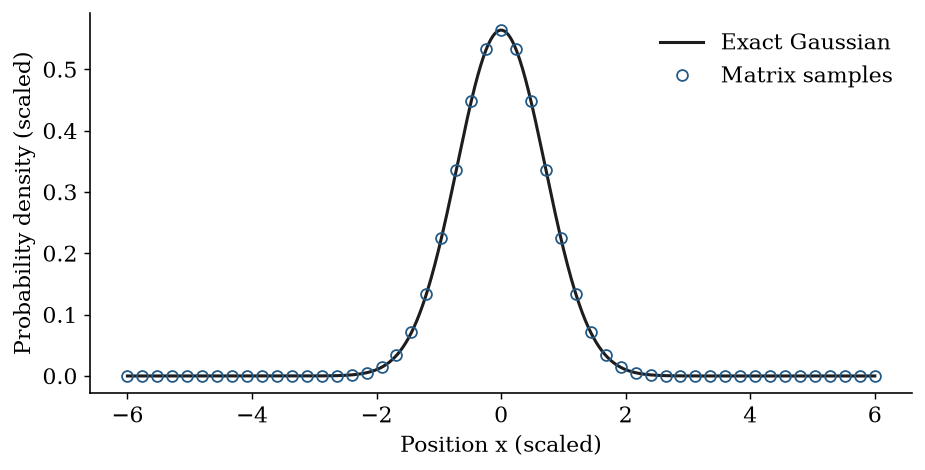

In [21]:
density_exact = np.exp(-x_osc**2) / np.sqrt(np.pi)
fig, ax = plt.subplots(figsize=(7, 3.5), layout="constrained")
ax.plot(x_osc, density_exact, color=BLACK, label="Exact Gaussian")
ax.plot(x_osc[::16], psi_harmonic[::16, 0]**2, "o", mfc="none", color=BLUE,
        label="Matrix samples")
ax.set(xlabel="Position x (scaled)", ylabel="Probability density (scaled)")
ax.legend(frameon=False)
plt.show()

**Read the figure.** Both the shape and the energy agree with known results. This is our check before trying a potential without a simple exact spectrum.

## 6. Change one line: an anharmonic oscillator

Add a positive quartic term. Far from the center, the potential rises more steeply.

$$V(x)=\frac12x^2+\lambda x^4,\qquad \lambda\ge0.$$

**Predict before running:** will the ground-state probability become wider or narrower?
Will the gaps between neighboring energy levels remain equal?

We keep the familiar matrix solver. The new physics enters through the potential array.

### Choose the strength of the extra confinement

**Learn**
- **TRY:** change `strength` to 0.0, 0.05, 0.5, or 1.0.
- Then rerun the remaining cells in Section 6.
- The figure shows the central region; the calculation still uses the full interval.

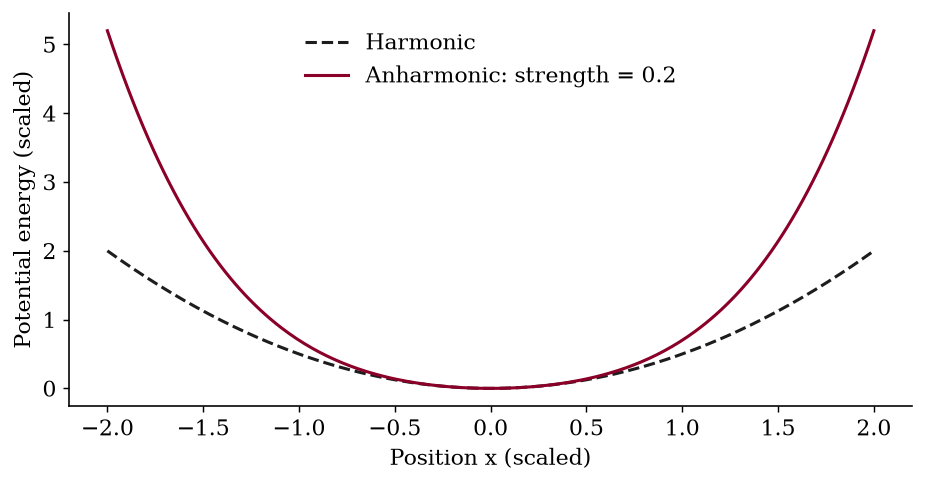

In [22]:
strength = 0.2  # TRY: 0.0, 0.05, 0.5, 1.0
V_anharmonic = 0.5 * x_osc**2 + strength * x_osc**4
x_potential = np.linspace(-2, 2, 301)

fig, ax = plt.subplots(figsize=(7, 3.6), layout="constrained")
ax.plot(x_potential, 0.5*x_potential**2, "--", color=BLACK, label="Harmonic")
ax.plot(x_potential, 0.5*x_potential**2 + strength*x_potential**4,
        color=RED, label=f"Anharmonic: strength = {strength:g}")
ax.set(xlabel="Position x (scaled)", ylabel="Potential energy (scaled)")
ax.legend(frameon=False)
plt.show()

**Read the figure.** The bottom of both potentials is at zero. A positive extra term raises the potential away from the origin.

### Solve the new potential

**Learn**
- The matrix function is unchanged.
- The output now supplies energies for which we have no simple exact formula.

In [23]:
E_anharmonic, psi_anharmonic = matrix_states(x_osc, V_anharmonic, n_states=4)
print("Harmonic energies:  ", E_harmonic)
print("Anharmonic energies:", E_anharmonic)
print("Harmonic gaps:      ", np.diff(E_harmonic))
print("Anharmonic gaps:    ", np.diff(E_anharmonic))

Harmonic energies:   [0.499993 1.499965 2.499909 3.499824]
Anharmonic energies: [0.602393 1.950466 3.536058 5.290732]
Harmonic gaps:       [0.999972 0.999944 0.999916]
Anharmonic gaps:     [1.348073 1.585592 1.754673]


### Read the energy ladders

**Learn**
- Each horizontal line is an energy eigenvalue.
- Both ladders use the same energy scale and the same zero.

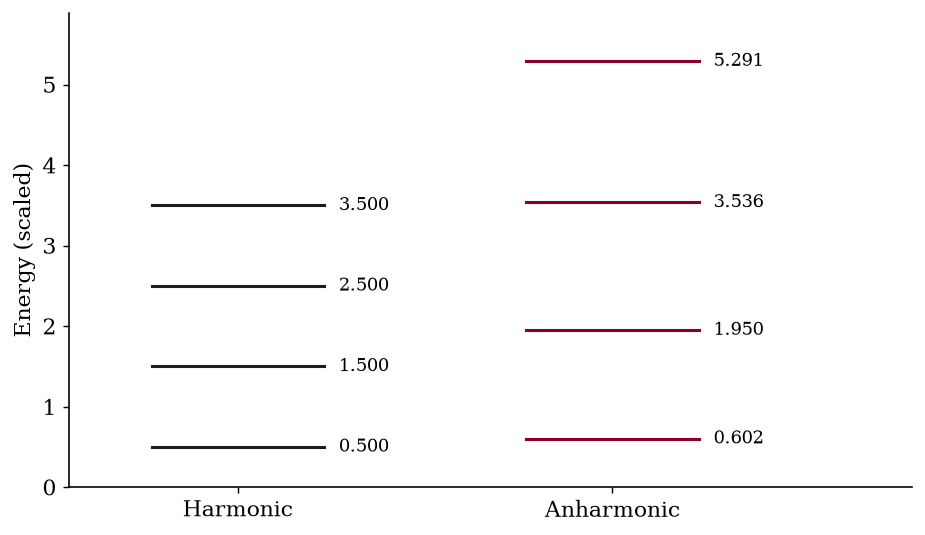

In [24]:
fig, ax = plt.subplots(figsize=(7, 4), layout="constrained")
for xpos, levels, color in [(0, E_harmonic, BLACK), (1, E_anharmonic, RED)]:
    for n, energy in enumerate(levels):
        ax.plot([xpos-0.23, xpos+0.23], [energy, energy], color=color)
        ax.text(xpos+0.27, energy, f"{energy:.3f}", va="center", fontsize=10)
ax.set(xticks=[0, 1], xticklabels=["Harmonic", "Anharmonic"],
       ylabel="Energy (scaled)", xlim=(-0.45, 1.8),
       ylim=(0, max(E_anharmonic[-1], E_harmonic[-1]) + 0.6))
plt.show()

**Read the figure.** The harmonic ladder has equal gaps. With positive quartic confinement, higher states are shifted more strongly and the gaps are no longer equal.

### Where is the particle?

**Learn**
- Both densities are normalized to total probability one.
- Use the same horizontal and vertical scales for comparison.

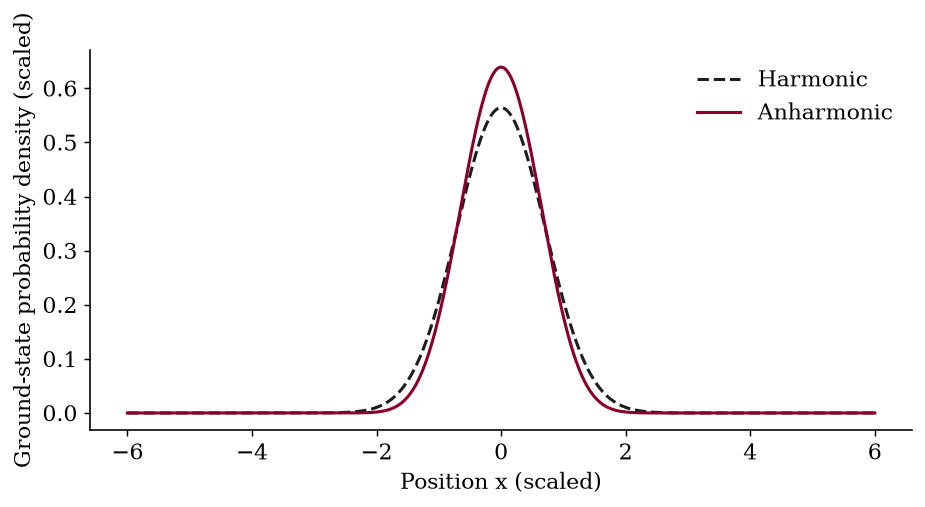

RMS position: harmonic 0.7071; anharmonic 0.6082


In [25]:
fig, ax = plt.subplots(figsize=(7, 3.5), layout="constrained")
ax.plot(x_osc, psi_harmonic[:, 0]**2, "--", color=BLACK, label="Harmonic")
ax.plot(x_osc, psi_anharmonic[:, 0]**2, color=RED, label="Anharmonic")
ax.set(xlabel="Position x (scaled)", ylabel="Ground-state probability density (scaled)")
ax.legend(frameon=False)
plt.show()
width_harmonic = np.sqrt(np.trapezoid(x_osc**2 * psi_harmonic[:, 0]**2, x_osc))
width_anharmonic = np.sqrt(np.trapezoid(x_osc**2 * psi_anharmonic[:, 0]**2, x_osc))
print(f"RMS position: harmonic {width_harmonic:.4f}; anharmonic {width_anharmonic:.4f}")

**Read the figure.** Stronger confinement gives a narrower ground-state distribution. The printed RMS position measures its width; the mean position is zero by symmetry.

### Repeat for several strengths

**Learn**
- A loop replaces repeated manual edits.
- Compare the first three gaps, not just the ground-state energy.

In [26]:
strengths = np.array([0.0, 0.05, 0.1, 0.2, 0.5, 1.0])
scan_energies = []
for value in strengths:
    potential = 0.5*x_osc**2 + value*x_osc**4
    energies, _ = matrix_states(x_osc, potential, n_states=4)
    scan_energies.append(energies)
scan_energies = np.array(scan_energies)
gaps = np.diff(scan_energies, axis=1)

### See the equal spacing disappear

**Learn**
- At zero quartic strength, all three gaps are approximately one.
- The small mismatch at zero is a grid error.

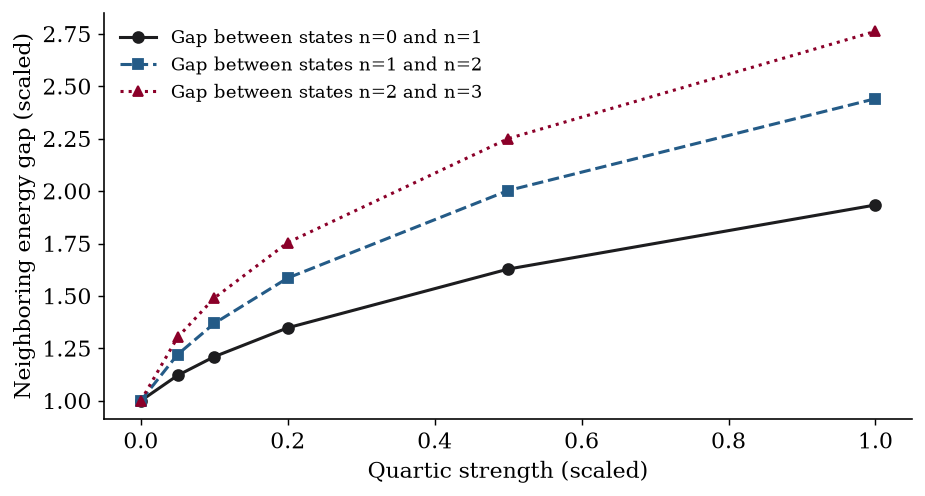

In [27]:
fig, ax = plt.subplots(figsize=(7, 3.7), layout="constrained")
for j, (color, style) in enumerate(zip([BLACK, BLUE, RED], ["o-", "s--", "^:"])):
    ax.plot(strengths, gaps[:, j], style, color=color,
            label=f"Gap between states n={j} and n={j+1}")
ax.set(xlabel="Quartic strength (scaled)", ylabel="Neighboring energy gap (scaled)")
ax.legend(frameon=False, fontsize=10)
plt.show()

**Read the figure.** One code now answers a physical question across a family of potentials. Every curve comes from the same grid and solver.

## 7. No exact answer: what can we check?

We already tested the code on the box and harmonic oscillator.
For the anharmonic oscillator, also separate two numerical choices:

1. **Grid spacing:** fix the computational interval and add more points.
2. **Outer boundary:** keep the spacing fixed and move the walls farther away.

Change one choice at a time. A stable displayed decimal is more convincing than a smooth-looking plot.

### Run two independent convergence checks

**Learn**
- These checks use quartic strength 0.2, regardless of your earlier edit.
- The first changes spacing only; the second changes the boundary only.

In [28]:
check_strength = 0.2
grid_counts = [200, 400, 800, 1600]
grid_energies = []
for count in grid_counts:
    x = np.linspace(-6, 6, count + 1)
    energies, _ = matrix_states(x, 0.5*x**2 + check_strength*x**4)
    grid_energies.append(energies[0])

radii = [2.0, 3.0, 4.0, 6.0]
boundary_energies = []
for radius in radii:
    count = round(2*radius / 0.02)
    x = np.linspace(-radius, radius, count + 1)
    energies, _ = matrix_states(x, 0.5*x**2 + check_strength*x**4)
    boundary_energies.append(energies[0])
print("Grid refinement:")
for n, e in zip(grid_counts, grid_energies):
    print(f"  {n:4d} intervals: E = {e:.8f}")
print("Move the boundary (spacing fixed at 0.02):")
for r, e in zip(radii, boundary_energies):
    print(f"  walls at +/-{r:g}: E = {e:.8f}")

Grid refinement:
   200 intervals: E = 0.60220730
   400 intervals: E = 0.60235570
   800 intervals: E = 0.60239280
  1600 intervals: E = 0.60240207
Move the boundary (spacing fixed at 0.02):
  walls at +/-2: E = 0.61295349
  walls at +/-3: E = 0.60238434
  walls at +/-4: E = 0.60238318
  walls at +/-6: E = 0.60238318


### Watch successive answers settle

**Learn**
- The vertical axis is the change between successive calculations.
- A very small last change may reach floating-point noise; it is not an exact error bar.

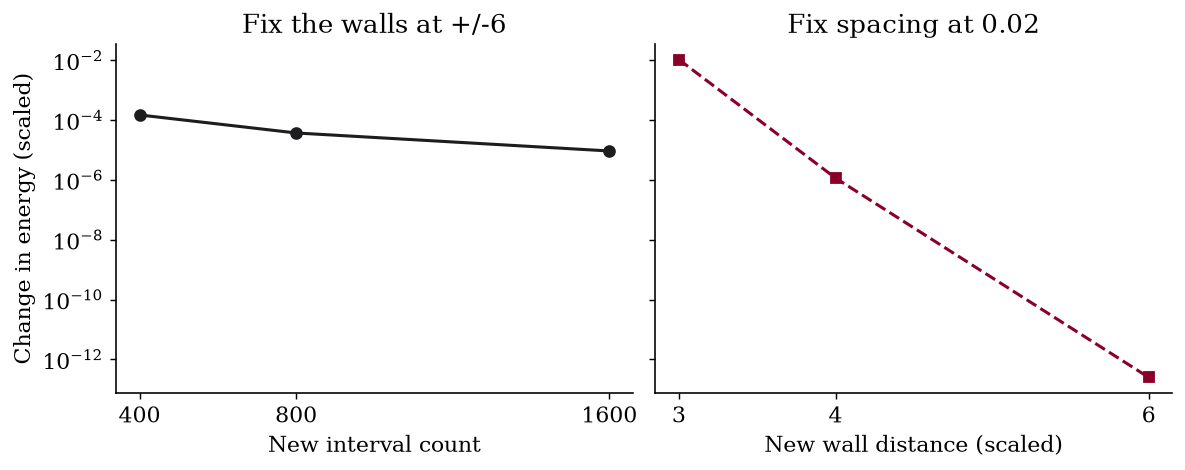

In [29]:
grid_changes = np.abs(np.diff(grid_energies))
boundary_changes = np.abs(np.diff(boundary_energies))
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5), sharey=True, layout="constrained")
axes[0].semilogy(grid_counts[1:], grid_changes, "o-", color=BLACK)
axes[0].set(xlabel="New interval count", title="Fix the walls at +/-6")
axes[1].semilogy(radii[1:], np.maximum(boundary_changes, 1e-14), "s--", color=RED)
axes[1].set(xlabel="New wall distance (scaled)", title="Fix spacing at 0.02")
axes[0].set_ylabel("Change in energy (scaled)")
axes[0].set_xticks(grid_counts[1:])
axes[1].set_xticks(radii[1:])
plt.show()

**Read the figure.** Both panels share one vertical scale. The right-hand plot uses a display floor of 1e-14 for differences below roundoff resolution; the printed energies above remain unchanged. Moving distant walls cannot remove grid error.

## 8. Explore potentials without a simple exact spectrum

The next examples use **the same `matrix_states` function**. Only the potential changes.
We use smooth model potentials; their low-energy spectra generally need numerical or approximate methods.
All positions, energies, and parameters below use the same scaled units as before.

Start with **two connected wells**. Classically, a particle below the central barrier would
stay in one well. A quantum eigenstate can extend across both wells.

$$V(x)=b(x^2-a^2)^2,\qquad a=1.5,\quad b=0.5.$$

The minima are at the two positions specified by `a`. Their potential is zero;
the barrier height at the center is `b*a**4`.

**Predict:** will the ground state choose only the left well, only the right well, or both?

### Write one new potential

**Learn**
- Use a symmetric grid and solve for the two lowest states.
- The same boundary condition is imposed at the distant endpoints.
- TRY: change `barrier_strength` from 0.5 to 1.0, then rerun this cell and the next.

In [30]:
x_new = np.linspace(-6, 6, 1201)
well_position = 1.5
barrier_strength = 0.5  # TRY: 0.2, 0.5, 1.0
V_double = barrier_strength * (x_new**2 - well_position**2)**2
E_double, psi_double = matrix_states(x_new, V_double, n_states=2)
print(f"Central barrier: {barrier_strength * well_position**4:.4f}")
print("Lowest energies:", E_double)
print(f"Energy splitting: {E_double[1] - E_double[0]:.6f}")

Central barrier: 2.5312
Lowest energies: [1.291495 1.432807]
Energy splitting: 0.141312


### Two wells, two different wavefunctions

**Learn**
- The ground state is even; the first excited state is odd and has a node at the center.
- A finite symmetric double well has a ground state spread over both wells.
- The sign of a wavefunction matters for interference; its square gives probability density.

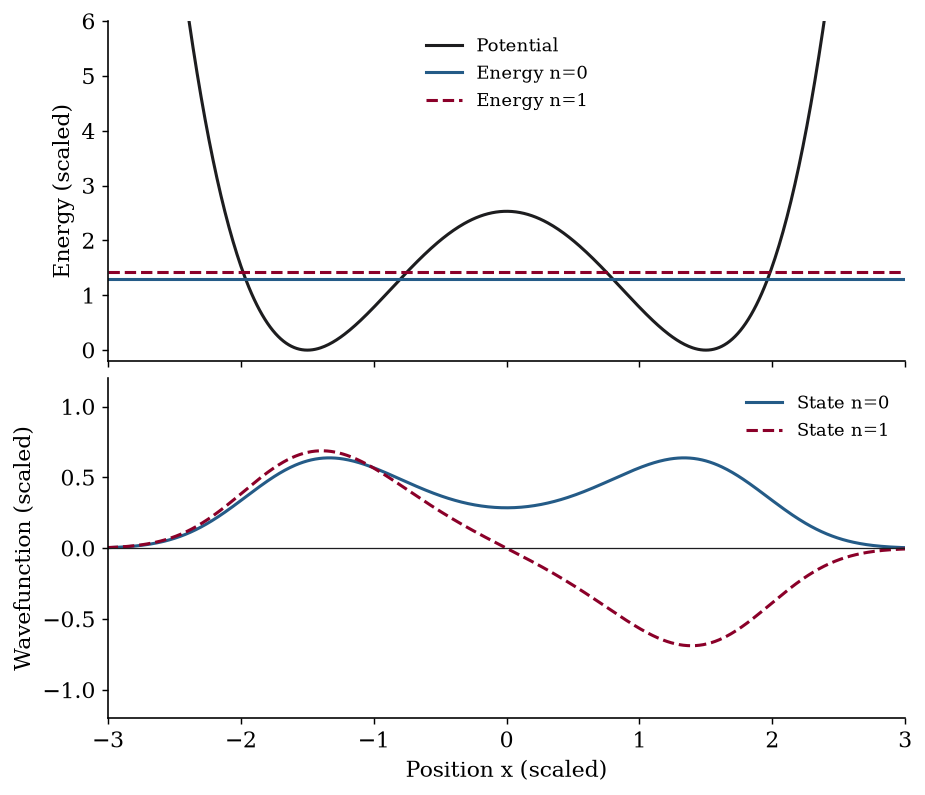

In [31]:
fig, axes = plt.subplots(2, 1, figsize=(7, 6), sharex=True, layout="constrained")
axes[0].plot(x_new, V_double, color=BLACK, label="Potential")
for n, (color, style) in enumerate([(BLUE, "-"), (RED, "--")]):
    axes[0].axhline(E_double[n], color=color, ls=style, label=f"Energy n={n}")
    axes[1].plot(x_new, psi_double[:, n], color=color, ls=style, label=f"State n={n}")
axes[0].set(ylabel="Energy (scaled)", ylim=(-0.2, 6))
axes[1].axhline(0, color=BLACK, lw=0.7)
axes[1].set(xlabel="Position x (scaled)", ylabel="Wavefunction (scaled)",
            xlim=(-3, 3), ylim=(-1.2, 1.2))
for ax in axes:
    ax.legend(frameon=False, fontsize=10, loc="upper right")
axes[0].legend(frameon=False, fontsize=10, loc="upper center")
plt.show()

**Read the figure.** For the default parameters, both energies lie below the central barrier, yet both wavefunctions extend into it. The ground state does not pick a side. The plots show the central region; the computation includes the full interval from -6 to 6, where the outer potential is much higher.

### Use one plotting function for comparisons

**Learn**
- Each column shows a potential and its two lowest energy levels above, then the ground-state density below.
- All columns share their position, energy, and density scales.
- The function prints the energy splitting and probability of being on the left.

In [32]:
def compare_potentials(x, potentials, titles, energy_limits):
    fig, axes = plt.subplots(2, len(potentials), figsize=(10, 5.5),
                             sharex=True, sharey="row")
    fig.subplots_adjust(left=0.10, right=0.99, bottom=0.12, top=0.85, wspace=0.12, hspace=0.08)
    for j, (potential, title) in enumerate(zip(potentials, titles)):
        energies, waves = matrix_states(x, potential, n_states=2)
        axes[0, j].plot(x, potential, color=BLACK)
        axes[0, j].axhline(energies[0], color=BLUE, ls="-")
        axes[0, j].axhline(energies[1], color=RED, ls="--")
        axes[0, j].set(title=title, ylim=energy_limits)
        axes[1, j].plot(x, waves[:, 0]**2, color=BLUE)
        axes[1, j].fill_between(x, waves[:, 0]**2, color=BLUE, alpha=0.12)
        axes[1, j].set(xlabel="Position x (scaled)", xlim=(-4, 4), ylim=(0, 1.6))
        left = x <= 0
        p_left = np.trapezoid(waves[left, 0]**2, x[left])
        print(f"{title}: gap = {energies[1]-energies[0]:.5f}; P(left) = {p_left:.3f}")
    axes[0, 0].set_ylabel("Energy (scaled)")
    axes[1, 0].set_ylabel("Ground-state density (scaled)")
    fig.legend(axes[0, 0].lines, ["Potential", "Ground energy", "First excited energy"],
               loc="upper center", bbox_to_anchor=(0.5, 0.99),
               ncol=3, frameon=False, fontsize=10)
    plt.show()

For every comparison below, **black = potential**, **blue solid line = ground energy**,
and **red dashed line = first excited energy** in the upper row.
The lower row shows **ground-state probability density**. These are separate vertical axes;
the density is not added to the energy. The central display window is from -4 to 4;
the calculation still extends from -6 to 6. Outer parts of the potential rise beyond the displayed energy range.

### Raise the central barrier

**Learn**
- Keep the well positions fixed and vary the quartic coefficient.
- A higher barrier reduces density between the wells, but symmetry keeps equal left and right probabilities.
- Changing this coefficient also changes each well’s curvature; it is not a barrier-only modification.

Barrier height = 1.01: gap = 0.29248; P(left) = 0.500
Barrier height = 2.53: gap = 0.14131; P(left) = 0.500
Barrier height = 10.12: gap = 0.00541; P(left) = 0.500


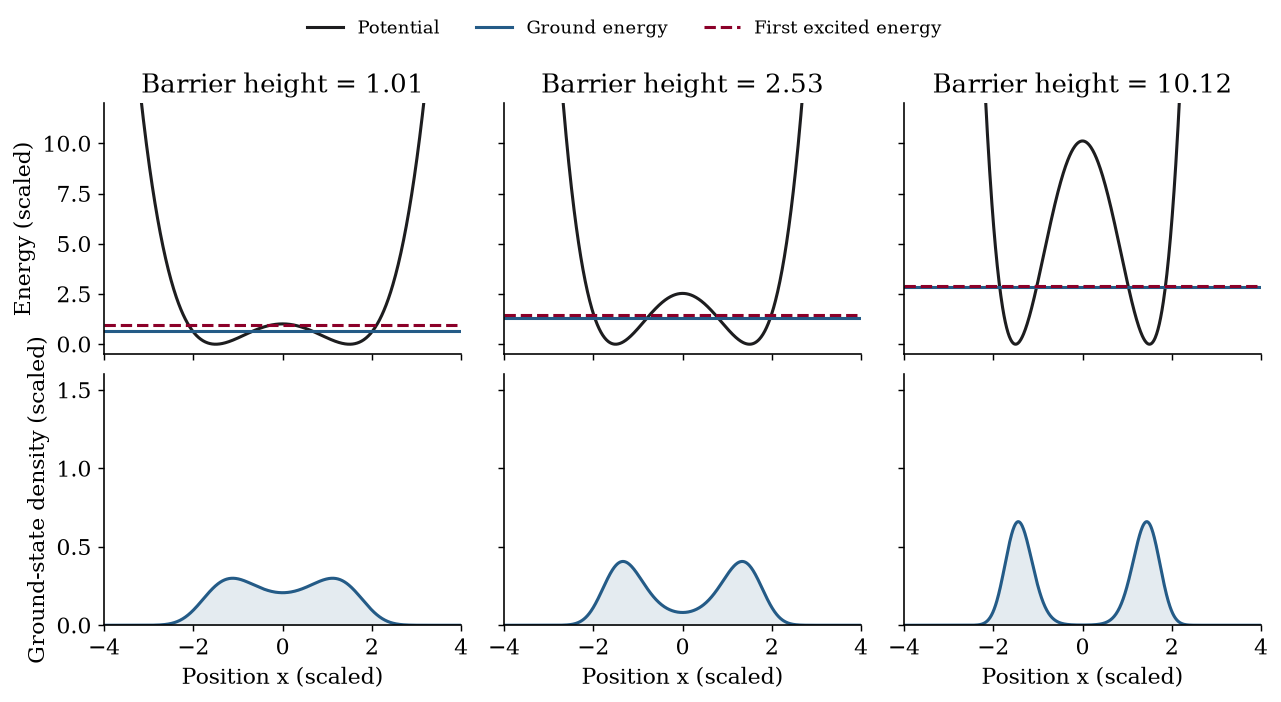

In [33]:
barrier_values = [0.2, 0.5, 2.0]
barrier_potentials = [b * (x_new**2 - 1.5**2)**2 for b in barrier_values]
barrier_titles = [f"Barrier height = {b*1.5**4:.2f}" for b in barrier_values]
compare_potentials(x_new, barrier_potentials, barrier_titles, (-0.5, 12))

**Read the figure.** The two lowest energy lines approach each other as the central barrier grows. For the highest barrier they nearly overlap on this scale, but remain distinct. In all three symmetric cases, the ground state has probability one half on each side.

### Resolve the small energy splitting

**Learn**
- Subtract the two energies to see a difference that is hard to read from the level diagram.
- For this family, a higher barrier makes the lowest pair closer in energy.

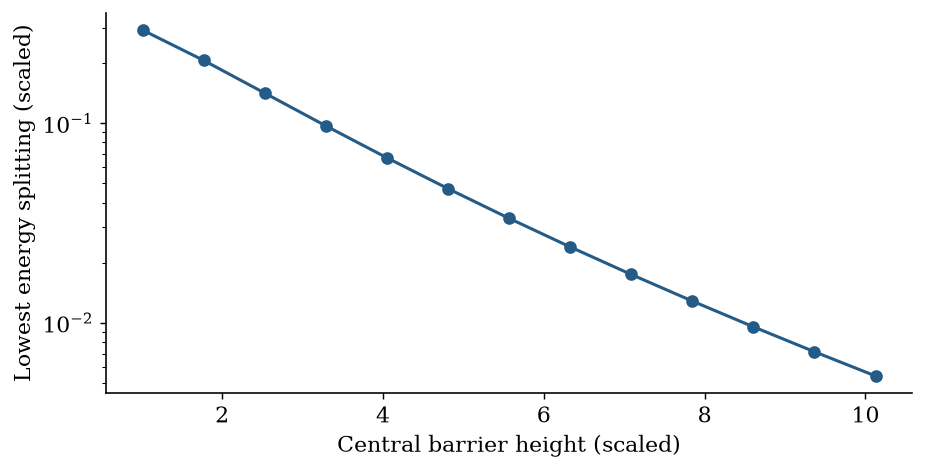

In [34]:
barrier_scan = np.linspace(0.2, 2.0, 13)
splittings = []
for b in barrier_scan:
    energies, _ = matrix_states(x_new, b*(x_new**2 - 1.5**2)**2, n_states=2)
    splittings.append(energies[1] - energies[0])
fig, ax = plt.subplots(figsize=(7, 3.5), layout="constrained")
ax.semilogy(barrier_scan * 1.5**4, splittings, "o-", color=BLUE)
ax.set(xlabel="Central barrier height (scaled)",
       ylabel="Lowest energy splitting (scaled)")
plt.show()

**Read the figure.** These are finite, positive splittings, not exact degeneracies. A logarithmic vertical axis makes small values visible. The near equality of the lowest pair is a signature of weak coupling between the wells.

### Break the symmetry with one extra term

$$V(x)=0.5(x^2-1.5^2)^2+F x.$$

A positive `tilt` raises the right side and lowers the left side.
**Predict:** which side should contain more ground-state probability?

### Tilt the double well

**Learn**
- Add a linear term to the same symmetric double well.
- The ground state favors the lower well when the bias competes with the small splitting.
- TRY: replace 0.15 by 0.03 and -0.15 by -0.03 to make a weaker bias.

Tilt = -0.15: gap = 0.40428; P(left) = 0.039
Tilt = +0.00: gap = 0.14131; P(left) = 0.500
Tilt = +0.15: gap = 0.40428; P(left) = 0.961


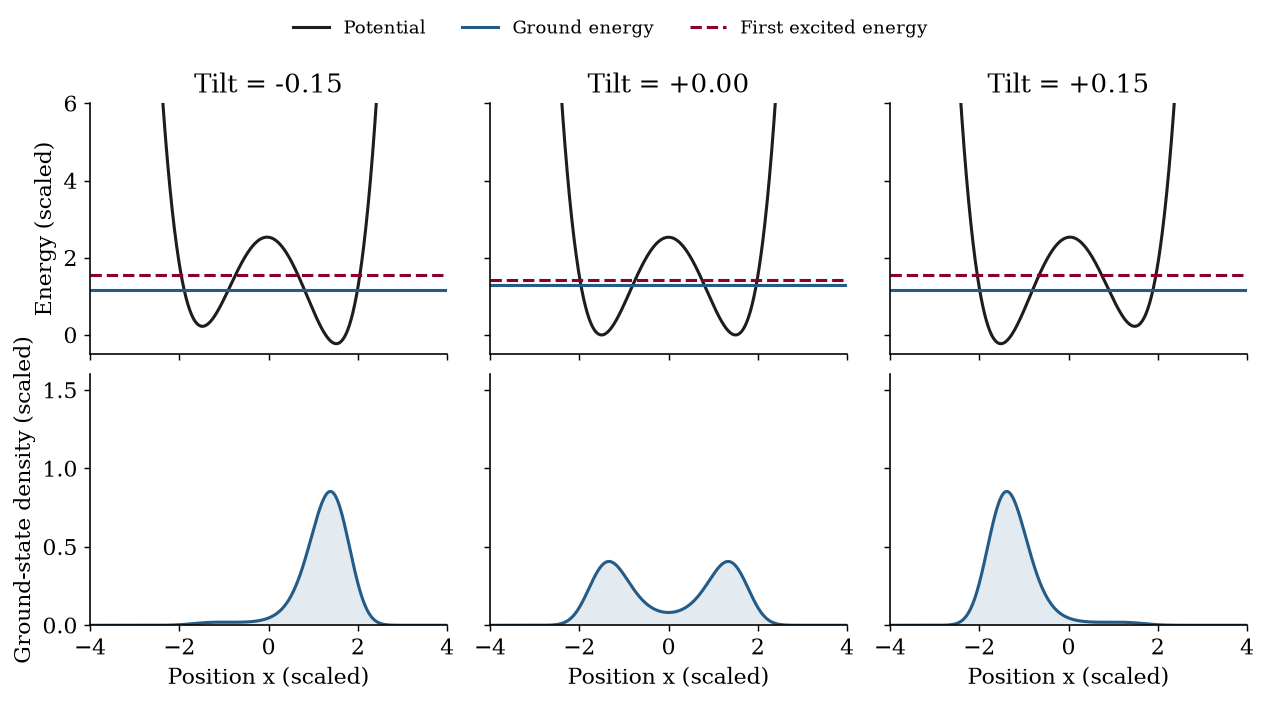

In [35]:
tilts = [-0.15, 0.0, 0.15]  # TRY: [-0.03, 0.0, 0.03]
tilted_potentials = [0.5*(x_new**2 - 1.5**2)**2 + tilt*x_new for tilt in tilts]
tilt_titles = [f"Tilt = {tilt:+.2f}" for tilt in tilts]
compare_potentials(x_new, tilted_potentials, tilt_titles, (-0.5, 6))

**Read the figure.** Positive tilt favors the left well; negative tilt favors the right. The ground state becomes mostly localized, rather than exactly confined to one side. The printed left probability measures this change; the center column remains symmetric.

### Three more shapes: change only the potential

No new eigensolver is needed. Each expression below is a smooth modification of a confining trap.

1. **Narrow barrier:** add a Gaussian bump at the center. Does the density avoid it?
2. **Off-center dip:** subtract a Gaussian away from the center. Does it attract probability?
3. **Corrugated trap:** add a cosine modulation and a small tilt. Does density simply copy the potential minima?

These examples have no simple exact spectrum used here. A potential minimum alone does not determine
the density: the kinetic-energy term also matters, especially for narrow features.

### Try three potentials with the same solver

**Learn**
- Every potential is a NumPy array evaluated on the existing grid.
- The three columns use the same axes; read densities separately from energies.
- TRY: change the barrier height 6.0, dip depth 4.0, or ripple height 1.2.

Narrow barrier: gap = 0.10943; P(left) = 0.500
Off-center dip: gap = 1.11740; P(left) = 0.034
Corrugated trap: gap = 0.54231; P(left) = 0.569


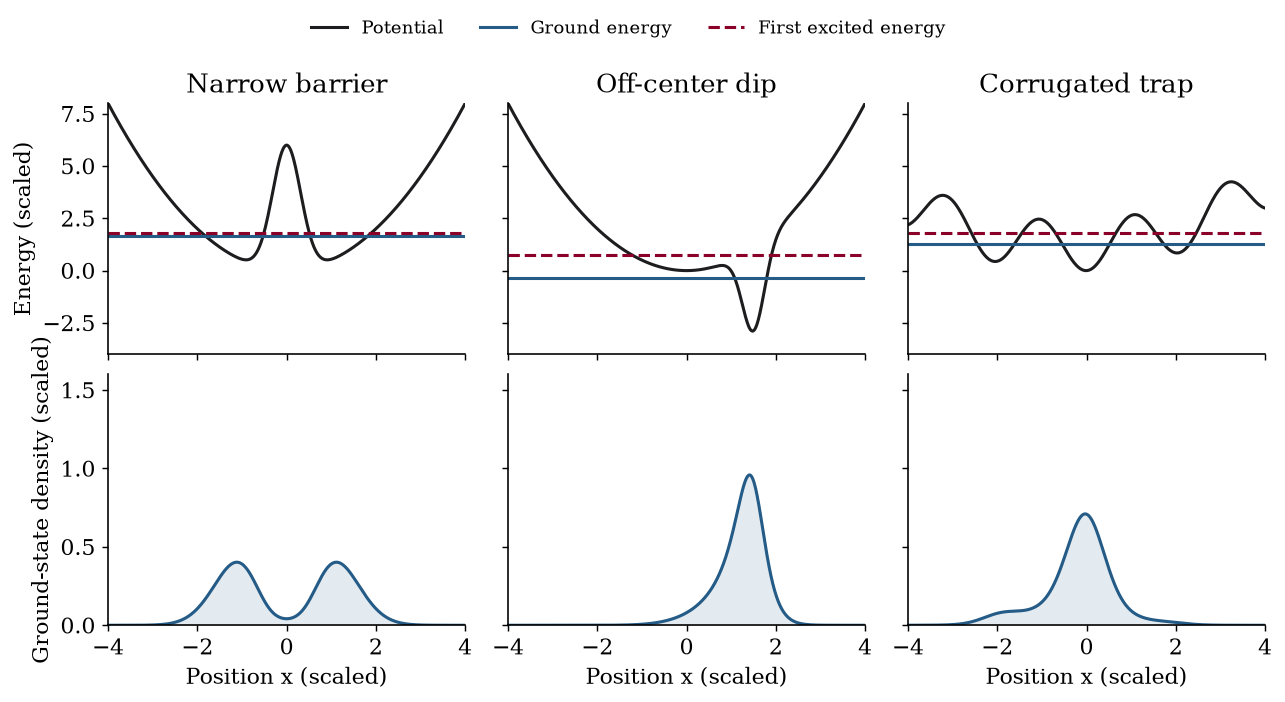

In [36]:
V_bump = 0.5*x_new**2 + 6.0*np.exp(-(x_new/0.45)**2)
V_dip = 0.5*x_new**2 - 4.0*np.exp(-((x_new-1.5)/0.35)**2)
V_ripple = 0.15*x_new**2 + 1.2*(1-np.cos(3*x_new)) + 0.1*x_new
shape_potentials = [V_bump, V_dip, V_ripple]
shape_titles = ["Narrow barrier", "Off-center dip", "Corrugated trap"]
compare_potentials(x_new, shape_potentials, shape_titles, (-4, 8))

**Read the figure.** The narrow barrier suppresses the central density, the off-center dip pulls probability toward the right, and the corrugated trap produces structure on several length scales. With these defaults, less than 0.004% of each ground-state probability lies outside the displayed position window. Smooth curves alone do not guarantee accuracy: refine the grid when narrowing a feature and move the boundaries when weakening confinement.

### Optional: watch probability move between the wells

A single energy eigenstate has a stationary probability density. To see motion,
**combine the two lowest states** of the symmetric double well.
Choose their relative sign so the initial state is mostly on the left.

$$\Psi(x,t)=\frac{\psi_0(x)+e^{-i(E_1-E_0)t}\psi_1(x)}{\sqrt{2}},
\qquad T=\frac{2\pi}{E_1-E_0}.$$

We dropped a common phase, which does not change the density, and use scaled time with reduced Planck's
constant equal to one. This is exact time evolution of this chosen two-state superposition within
the computed eigenbasis. It does not represent every possible initial wavepacket.

### Make a moving state from two stationary states

**Learn**
- The relative phase changes with time; squaring the sum produces a changing density.
- A smaller energy splitting means a longer oscillation period.
- No additional differential-equation solver is needed for this example.

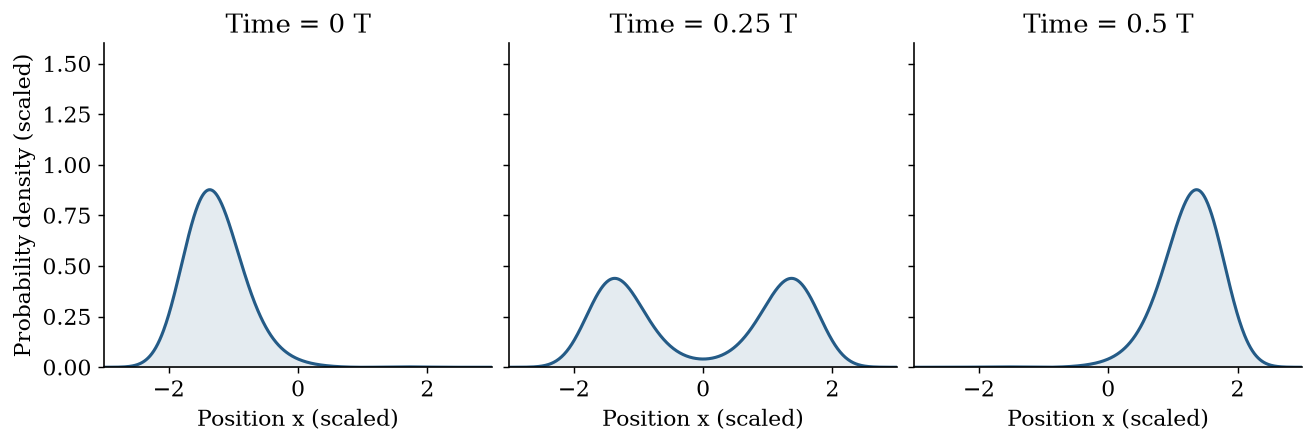

Full oscillation period: 44.463 (scaled time)


In [37]:
even, odd = psi_double[:, 0].copy(), psi_double[:, 1].copy()
if np.trapezoid(x_new * even * odd, x_new) > 0:
    odd *= -1  # Choose the relative sign to start on the left.
splitting = E_double[1] - E_double[0]
period = 2*np.pi / splitting
fractions = [0.0, 0.25, 0.5]
fig, axes = plt.subplots(1, 3, figsize=(10, 3.3), sharex=True, sharey=True,
                          layout="constrained")
for ax, fraction in zip(axes, fractions):
    state = (even + np.exp(-2j*np.pi*fraction)*odd) / np.sqrt(2)
    density = np.abs(state)**2
    ax.plot(x_new, density, color=BLUE)
    ax.fill_between(x_new, density, color=BLUE, alpha=0.12)
    ax.set(xlabel="Position x (scaled)", title=f"Time = {fraction:g} T",
           xlim=(-3, 3), ylim=(0, 1.6))
axes[0].set_ylabel("Probability density (scaled)")
plt.show()
print(f"Full oscillation period: {period:.3f} (scaled time)")

**Read the figure.** Read left to right: probability begins mostly on the left, spreads across both wells, and becomes mostly right after half a period. It returns after one period. Each component eigenstate remains stationary; their interference changes. These densities are normalized, and the potential is held fixed.

## 9. Your turn

Work through these in order. Change one value at a time.

1. **Aim at the wall.** Try three energies around 4.9 in Section 2. Which side of zero does each trial reach?
2. **Use fewer points.** In Section 2, change the box grid from 201 points to 41. Rerun through Section 3. Do the two methods still agree? Do they agree as well with the exact energy?
3. **Turn off the extra term.** Set `strength = 0.0` in Section 6. Do the two energy ladders and densities overlap?
4. **Strengthen confinement.** Compare `strength = 0.2` and `strength = 1.0`. Predict the change in the density width and energy gaps before running.
5. **Separate speed from accuracy.** Compare Python shooting, Numba shooting, and the matrix method in Section 4. Does a faster implementation reduce grid error?
6. **Choose a side.** In Section 8, make the tilt weaker. Does the left probability return toward one half?
7. **Invent a trap.** Change one number in the three-shape gallery. Predict the density, then check it. Refine the grid and move the boundaries before trusting a new result.

**Explain in one sentence:** why is agreement between shooting and the matrix method not enough to prove that the spatial grid is accurate?

### What we learned

- Boundary conditions select the allowed energies.
- Shooting and a matrix solver can solve the same discrete equations.
- A solver's speed and a discretization's accuracy are different questions.
- Changing the potential lets the same matrix code explore new physics.
- Known solutions, grid refinement, and boundary checks build confidence in a numerical result.

### References

- [SciPy: symmetric tridiagonal eigensolver](https://docs.scipy.org/doc/scipy/reference/generated/scipy.linalg.eigh_tridiagonal.html).
- [ETH Computational Quantum Physics, Exercise 2](https://edu.itp.phys.ethz.ch/fs11/cqp/exercise2.pdf): bound states and the anharmonic oscillator. That exercise also introduces Numerov and a basis expansion; this notebook keeps the simpler three-point grid method.
- [Netlib: tridiagonal eigenvalue methods](https://www.netlib.org/utk/people/JackDongarra/etemplates/node93.html): why selected tridiagonal eigenstates do not require dense full diagonalization.
- [Numba: a five-minute guide](https://numba.readthedocs.io/en/stable/user/5minguide.html): numerical loops, compilation, and separating first-call cost from repeated execution.
- [Song, Annals of Physics (2008)](https://arxiv.org/abs/0803.3113): further reading on tunneling and level splitting in double wells; the derivation is beyond this lesson.

All figures and numerical results above are generated by the code in this notebook.